# Data handling and visualization

In [64]:
# data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Import CSV, make columns lowercase and strip whitespacce

In [66]:
df = pd.read_csv('/Users/emjack5/Desktop/Data analysis/Capstone2 files/US Airline Flight Routes and Fares 1993-2024.csv')

df_raw = df.copy()

/var/folders/62/h1vk7lw13g73qsk07s3l1cwm0000gn/T/ipykernel_24611/2243734017.py:1: DtypeWarning: Columns (19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/emjack5/Desktop/Data analysis/Capstone2 files/US Airline Flight Routes and Fares 1993-2024.csv')


In [68]:
df.columns = df.columns.str.strip().str.lower()

In [70]:
print(df.columns[19], df.columns[20])


geocoded_city1 geocoded_city2


In [72]:
df['geocoded_city1'] = df['geocoded_city1'].astype('string')
df['geocoded_city2'] = df['geocoded_city2'].astype('string')


In [74]:
df.head(5)

,year,quarter,citymarketid_1,citymarketid_2,city1,city2,airportid_1,airportid_2,airport_1,airport_2,...,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low,geocoded_city1,geocoded_city2,tbl1apk
0,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,14112,ABE,PIE,...,81.43,G4,1.0000,81.43,G4,1.0000,81.43,<NA>,<NA>,202131013514112ABEPIE
1,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,15304,ABE,TPA,...,208.93,DL,0.4659,219.98,UA,0.1193,154.11,<NA>,<NA>,202131013515304ABETPA
2,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,ABQ,DAL,...,184.56,WN,0.9968,184.44,WN,0.9968,184.44,<NA>,<NA>,202131014011259ABQDAL
3,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,ABQ,DFW,...,182.64,AA,0.9774,183.09,AA,0.9774,183.09,<NA>,<NA>,202131014011298ABQDFW
4,2021,3,30140,30466,"Albuquerque, NM","Phoenix, AZ",10140,14107,ABQ,PHX,...,177.11,WN,0.6061,184.49,AA,0.3939,165.77,<NA>,<NA>,202131014014107ABQPHX


## Data Cleansing
This section will include all data preparation steps such as:
- Handling missing values
- Removing duplicates
- Data type conversions
- Feature engineering
- Filtering by year (Post 2010)

In [76]:
# Count total missing values per column
missing_summary = df.isnull().sum().sort_values(ascending=False)
print("Missing values by column:")
print(missing_summary[missing_summary > 0])


Missing values by column:
geocoded_city2    39206
geocoded_city1    39206
fare_low           1612
lf_ms              1612
carrier_low        1612
fare_lg            1540
large_ms           1540
carrier_lg         1540
dtype: int64


In [78]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])


geocoded_city2    15.940314
geocoded_city1    15.940314
fare_low           0.655404
lf_ms              0.655404
carrier_low        0.655404
fare_lg            0.626131
large_ms           0.626131
carrier_lg         0.626131
dtype: float64


In [80]:
#Drop unecessary columns

columns_to_drop = [
    'geocoded_city1',
    'geocoded_city2',
    'citymarketid_1',
    'citymarketid_2',
    'airportid_1',
    'airportid_2',
    'airport_1',
    'airport_2',
    'carrier_lg',
    'large_ms',
    'fare_lg',
    'carrier_low',
    'fare_low',
    'lf_ms',
    'tbl1apk'
]

df = df.drop(columns=columns_to_drop, errors='ignore')

#change nsmiles 'column' to 'distance'
df = df.rename(columns={'nsmiles': 'distance'})

# Preview the dataset
print(df.columns.tolist())
df.head(5)

['year', 'quarter', 'city1', 'city2', 'distance', 'passengers', 'fare']


,year,quarter,city1,city2,distance,passengers,fare
0,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",970,180,81.43
1,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",970,19,208.93
2,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",580,204,184.56
3,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",580,264,182.64
4,2021,3,"Albuquerque, NM","Phoenix, AZ",328,398,177.11


# Check for full duplicate rows, Drop full duplicates if any, Check for partial duplicates

In [82]:
full_duplicates = df.duplicated()
print(f"Number of fully duplicated rows: {full_duplicates.sum()}")

df = df.drop_duplicates()

partial_duplicates = df.duplicated(
    subset=['city1', 'city2', 'year', 'quarter']
)
print(f"Potential partial duplicates based on route and time: {partial_duplicates.sum()}")

Number of fully duplicated rows: 1
Potential partial duplicates based on route and time: 172380


# The dataset contains multiple records per route-quarter, likely representing different carriers or fare observations. Since the analytical grain for this project is route-quarter, records are aggregated prior to modeling to prevent duplicate inflation.

In [84]:
df.groupby(['city1','city2','year','quarter']).size().describe()

count    73574.000000
mean         3.342947
std          2.485533
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         33.000000
dtype: float64

# Route-quarter observations average ~3.3 records per group, confirming that the raw dataset contains multiple carrier-level entries per route-quarter. Aggregation to the route-quarter level is therefore necessary to avoid duplicate inflation in revenue calculations.

In [86]:
route_counts = (
    df.groupby(['city1','city2','year','quarter'])
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
)

route_counts.head()

,city1,city2,year,quarter,count
51668,"Los Angeles, CA (Metropolitan Area)","New York City, NY (Metropolitan Area)",1993,4,33
51665,"Los Angeles, CA (Metropolitan Area)","New York City, NY (Metropolitan Area)",1993,1,33
51669,"Los Angeles, CA (Metropolitan Area)","New York City, NY (Metropolitan Area)",1994,1,33
51666,"Los Angeles, CA (Metropolitan Area)","New York City, NY (Metropolitan Area)",1993,2,32
51667,"Los Angeles, CA (Metropolitan Area)","New York City, NY (Metropolitan Area)",1993,3,32


# Data Validation Checks
The following checks ensure that key fields fall within expected business constraints before aggregation and modeling.

In [88]:
def check_invalid(label, condition):
    invalid = df[condition]
    print(f"{label}: {len(invalid)} rows")
    return invalid.head()

invalid_years = check_invalid(
    "Invalid Year values",
    (df['year'] < 1993) | (df['year'] > 2024)
)

invalid_quarters = check_invalid(
    "Invalid Quarter values",
    ~df['quarter'].isin([1, 2, 3, 4])
)

invalid_fares = check_invalid(
    "Invalid Fare values (≤ 0 or missing)",
    (df['fare'] <= 0) | (df['fare'].isna())
)

invalid_passengers = check_invalid(
    "Invalid Passenger values (< 0)",
    df['passengers'] < 0
)

invalid_distance = check_invalid(
    "Invalid Distance values",
    (df['distance'] <= 0) | (df['distance'] > 5000)
)

invalid_routes = check_invalid(
    "Invalid Route records",
    df['city1'].isna() |
    df['city2'].isna() |
    (df['city1'] == df['city2'])
)

Invalid Year values: 0 rows
Invalid Quarter values: 0 rows
Invalid Fare values (≤ 0 or missing): 0 rows
Invalid Passenger values (< 0): 0 rows
Invalid Distance values: 0 rows
Invalid Route records: 0 rows


# No invalid records were identified across year, quarter, fare, passenger volume, distance,or route definitions; therefore, no rows were removed during the data cleaning stage

In [90]:
cols = ['year','quarter','fare','passengers']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

In [92]:
print("Missing values after numeric conversion:")
print(df[['year','quarter','fare','passengers']].isna().sum())

Missing values after numeric conversion:
year          0
quarter       0
fare          0
passengers    0
dtype: int64


# Numeric fields were standardized using pd.to_numeric with coercion to ensure non-numeric values were safely converted to missing values and did not silently corrupt downstream calculations

# Removed residual index columns created during previous transformations or CSV exports to ensure clean schema prior to aggregation and modeling.

In [27]:
df = df.drop(columns=['level_0', 'index'], errors='ignore')

print(df.columns.tolist())
df.info()

['year', 'quarter', 'city1', 'city2', 'distance', 'passengers', 'fare']
<class 'pandas.core.frame.DataFrame'>
Index: 245954 entries, 0 to 245954
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   year        245954 non-null  int64  
 1   quarter     245954 non-null  int64  
 2   city1       245954 non-null  object 
 3   city2       245954 non-null  object 
 4   distance    245954 non-null  int64  
 5   passengers  245954 non-null  int64  
 6   fare        245954 non-null  float64
dtypes: float64(1), int64(4), object(2)
memory usage: 15.0+ MB


In [94]:
# Check null counts
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df)) * 100

null_summary = pd.DataFrame({
    "Null Count": null_counts,
    "Percent Null": null_pct
}).sort_values("Percent Null", ascending=False)

null_summary

,Null Count,Percent Null
year,0,0.0
quarter,0,0.0
city1,0,0.0
city2,0,0.0
distance,0,0.0
passengers,0,0.0
fare,0,0.0


Missing values were evaluated across all columns. Columns with significant missingness (>0) were assessed for relevance before modeling. Core variables (year, quarter, fare, passengers, city1, city2) showed minimal missingness, ensuring model reliability

In [96]:
expected_quarters = {1, 2, 3, 4}

year_quarter_sets = (
    df.groupby('year')['quarter']
      .apply(set)
)

for year, quarters in year_quarter_sets.items():
    if quarters != expected_quarters:
        print(f"Year {year} missing quarters: {expected_quarters - quarters}")

full_years = year_quarter_sets[year_quarter_sets.apply(lambda x: x == expected_quarters)]
print("Number of full years:", len(full_years))
print("Full years:", list(full_years.index))

Year 1994 missing quarters: {2, 3, 4}
Year 2024 missing quarters: {2, 3, 4}
Number of full years: 29
Full years: [1993, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [98]:
print(df['year'].min(), df['year'].max())
print(sorted(df['year'].unique())[:10], '...', sorted(df['year'].unique())[-10:])

1993 2024
[np.int64(1993), np.int64(1994), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003)] ... [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [110]:
# Remove partial-year data and years not outlined for analysis (e.g., 2024 only contains Q1)
# Keep only complete years within the analysis period: 2010–2023
# Create cleaned working copy
df_clean = df.copy()

# Standardize column names
df_clean.columns = df_clean.columns.str.strip().str.lower()

# Filter to analysis period: 2010–2023
df_analysis = df_clean[
    (df_clean['year'] >= 2010) &
    (df_clean['year'] <= 2023)
].copy()

# Keep only years with all 4 quarters
valid_years = df_analysis.groupby('year')['quarter'].nunique()
full_years = valid_years[valid_years == 4].index

df_analysis = df_analysis[df_analysis['year'].isin(full_years)].copy()

print("Full analysis years retained:", sorted(df_analysis['year'].unique()))

Full analysis years retained: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


In [102]:
print(df_analysis.columns.tolist())

['year', 'quarter', 'city1', 'city2', 'distance', 'passengers', 'fare']


# To ensure accurate year-over-year and seasonal comparisons, only full years (containing all four quarters) were retained. Partial-year data (e.g., incomplete 2024 records) was excluded to prevent artificial trend distortion

Years retained with all 4 quarters: 2010-2023

In [108]:
# Validate analysis dataset before aggregation
print("Current dataset shape:", df_analysis.shape)
print("Years retained:", sorted(df_analysis['year'].unique()))
print("Unique routes:", df_analysis.groupby(['city1', 'city2']).ngroups)


Current dataset shape: (112852, 7)
Years retained: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Unique routes: 912


In [116]:
# Check raw data grain before route-quarter aggregation
group_sizes = df_analysis.groupby(['city1', 'city2', 'year', 'quarter']).size()

In [118]:
print("Max rows in a single route-quarter group:", group_sizes.max())
print("\nTop duplicated route-quarter groups:")
print(group_sizes[group_sizes > 1].sort_values(ascending=False).head(10))

Max rows in a single route-quarter group: 30

Top duplicated route-quarter groups:
city1                                city2                                  year  quarter
Los Angeles, CA (Metropolitan Area)  New York City, NY (Metropolitan Area)  2014  3          30
                                                                            2011  2          30
                                                                            2012  4          29
                                                                            2010  3          29
                                                                            2011  1          29
                                                                            2014  1          29
                                                                                  2          29
                                                                            2011  3          29
                                                           

In [120]:
worst_key = group_sizes.idxmax()

subset = df_analysis.set_index(['city1','city2','year','quarter']) \
           .loc[[worst_key]] \
           .reset_index()

display(subset.head())
subset[['passengers','fare','distance']].describe()

,city1,city2,year,quarter,distance,passengers,fare
0,"Los Angeles, CA (Metropolitan Area)","New York City, NY (Metropolitan Area)",2011,2,2510,443,264.11
1,"Los Angeles, CA (Metropolitan Area)","New York City, NY (Metropolitan Area)",2011,2,2510,54,264.17
2,"Los Angeles, CA (Metropolitan Area)","New York City, NY (Metropolitan Area)",2011,2,2510,3,311.40
3,"Los Angeles, CA (Metropolitan Area)","New York City, NY (Metropolitan Area)",2011,2,2510,3,373.38
4,"Los Angeles, CA (Metropolitan Area)","New York City, NY (Metropolitan Area)",2011,2,2510,86,290.65


,passengers,fare,distance
count,30.000000,30.000000,30.0
mean,361.866667,307.373333,2510.0
std,1153.283221,63.576613,0.0
min,0.000000,189.100000,2510.0
25%,1.500000,266.580000,2510.0
50%,25.500000,297.765000,2510.0
75%,92.000000,332.320000,2510.0
max,6161.000000,489.030000,2510.0


In [124]:
print("Most duplicated group:", worst_key)
print("Rows in that group:", group_sizes.max())

Most duplicated group: ('Los Angeles, CA (Metropolitan Area)', 'New York City, NY (Metropolitan Area)', np.int64(2011), np.int64(2))
Rows in that group: 30


# The raw dataset contained multiple observations for the same route-year-quarter. To investigate this, I isolated the most duplicated group and reviewed its underlying records. This confirmed that the source data existed at a more detailed level than route-quarter, so aggregation was required to produce a consistent unit of analysis.

In [126]:
df_analysis = df[
    (df['year'] >= 2010) &
    (df['year'] <= 2023)
].copy()

# Estimate revenue at the original row level
df_analysis['estimated_revenue'] = df_analysis['fare'] * df_analysis['passengers']

# Aggregate to route-quarter level
route_quarter_agg = (
    df_analysis.groupby(['city1', 'city2', 'year', 'quarter'], as_index=False)
      .agg(
          distance=('distance', 'median'),
          total_passengers=('passengers', 'sum'),
          estimated_revenue=('estimated_revenue', 'sum')
      )
)

# Calculate passenger-weighted average fare
route_quarter_agg['avg_fare'] = (
    route_quarter_agg['estimated_revenue'] /
    route_quarter_agg['total_passengers']
)

I first calculated estimated revenue at the row level by multiplying fare by passengers. I then aggregated the data to the route-quarter level by summing passengers and estimated revenue. Average fare was recalculated as estimated revenue divided by total passengers, creating a passenger-weighted average fare. This same logic was then used to aggregate the data to the route-year level for the final analysis

Because the raw dataset includes multiple records per route-quarter (often representing different carriers), fares were aggregated using a passenger-weighted average to avoid bias from unweighted means.


Route-Quarter Aggregation Validation:

In [128]:
dupes_quarter = route_quarter_agg.duplicated(subset=['city1','city2','year','quarter']).sum()
print(f"Duplicate route-quarter rows after aggregation: {dupes_quarter}")

Duplicate route-quarter rows after aggregation: 0


In [130]:
route_quarter_agg.describe()

,year,quarter,distance,total_passengers,estimated_revenue,avg_fare
count,34746.000000,34746.000000,34746.000000,34746.000000,3.474600e+04,34746.000000
mean,2016.493237,2.502993,1109.690813,1085.158349,2.303489e+05,221.392516
std,4.026388,1.117840,633.667628,1667.279989,3.575832e+05,59.481484
min,2010.000000,1.000000,148.000000,27.000000,2.020200e+03,72.150000
25%,2013.000000,2.000000,625.000000,273.000000,6.205177e+04,176.356375
50%,2016.000000,3.000000,967.000000,527.000000,1.140913e+05,214.198960
75%,2020.000000,4.000000,1501.000000,1167.000000,2.482620e+05,261.213627
max,2023.000000,4.000000,2724.000000,24735.000000,5.961167e+06,677.121791


In [132]:
df_analysis.head()

,year,quarter,city1,city2,distance,passengers,fare,estimated_revenue
0,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",970,180,81.43,14657.40
1,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",970,19,208.93,3969.67
2,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",580,204,184.56,37650.24
3,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",580,264,182.64,48216.96
4,2021,3,"Albuquerque, NM","Phoenix, AZ",328,398,177.11,70489.78


In [134]:
pd.options.display.float_format = '{:,.2f}'.format
route_quarter_agg.head()
route_quarter_agg.describe()

,year,quarter,distance,total_passengers,estimated_revenue,avg_fare
count,"34,746.00","34,746.00","34,746.00","34,746.00","34,746.00","34,746.00"
mean,"2,016.49",2.50,"1,109.69","1,085.16","230,348.92",221.39
std,4.03,1.12,633.67,"1,667.28","357,583.21",59.48
min,"2,010.00",1.00,148.00,27.00,"2,020.20",72.15
25%,"2,013.00",2.00,625.00,273.00,"62,051.77",176.36
50%,"2,016.00",3.00,967.00,527.00,"114,091.34",214.20
75%,"2,020.00",4.00,"1,501.00","1,167.00","248,261.97",261.21
max,"2,023.00",4.00,"2,724.00","24,735.00","5,961,167.31",677.12


In [136]:
route_year_agg = (
    route_quarter_agg.groupby(['city1', 'city2', 'year'], as_index=False)
    .agg(
        distance=('distance', 'median'),
        total_passengers=('total_passengers', 'sum'),
        estimated_revenue=('estimated_revenue', 'sum')
    )
)

# Calculate passenger-weighted average fare at the yearly level
route_year_agg['avg_fare'] = (
    route_year_agg['estimated_revenue'] /
    route_year_agg['total_passengers']
)

# Create a readable route name column
route_year_agg['route'] = route_year_agg['city1'] + ' → ' + route_year_agg['city2']

I aggregated the route-quarter dataset into route-year level data by summing total passengers and estimated revenue for each route and year. I then recalculated average fare as estimated revenue divided by total passengers so the yearly fare reflects passenger volume. Finally, I created a readable route name by combining the origin and destination city fields.

Route-Year Aggregation Validation:

In [138]:
print(route_quarter_agg.columns)

Index(['city1', 'city2', 'year', 'quarter', 'distance', 'total_passengers',
       'estimated_revenue', 'avg_fare'],
      dtype='object')


In [140]:
route_year_agg.head()

,city1,city2,year,distance,total_passengers,estimated_revenue,avg_fare,route
0,"Albany, NY","Chicago, IL",2010,723.00,1239,"252,144.06",203.51,"Albany, NY → Chicago, IL"
1,"Albany, NY","Chicago, IL",2011,723.00,1228,"273,608.11",222.81,"Albany, NY → Chicago, IL"
2,"Albany, NY","Chicago, IL",2012,723.00,1207,"287,805.90",238.45,"Albany, NY → Chicago, IL"
3,"Albany, NY","Chicago, IL",2013,723.00,1177,"295,396.67",250.97,"Albany, NY → Chicago, IL"
4,"Albany, NY","Chicago, IL",2014,723.00,1202,"311,306.85",258.99,"Albany, NY → Chicago, IL"


In [142]:
dupes_year = route_year_agg.duplicated(
    subset=['city1', 'city2', 'year']
).sum()

print(f"Duplicate route-year rows after aggregation: {dupes_year}")

Duplicate route-year rows after aggregation: 0


In [144]:
print(route_year_agg['estimated_revenue'].describe(percentiles=[0.5,0.9,0.95,0.99]))

count        9,760.00
mean       820,051.58
std      1,354,082.39
min          2,020.20
50%        395,264.42
90%      2,036,603.80
95%      2,940,845.10
99%      5,896,607.45
max     21,002,064.48
Name: estimated_revenue, dtype: float64


In [148]:
top10_share_by_year = []

for year, group in route_quarter_agg.groupby('year'):
    group_sorted = group.sort_values('estimated_revenue', ascending=False)
    cutoff = int(len(group_sorted) * 0.1)
    
    share = (
        group_sorted.iloc[:cutoff]['estimated_revenue'].sum()
        / group_sorted['estimated_revenue'].sum()
    )
    
    top10_share_by_year.append((year, share))

top10_share_by_year[:10]

[(2010, np.float64(0.4305665505726799)),
 (2011, np.float64(0.4303278395007025)),
 (2012, np.float64(0.4294064204149233)),
 (2013, np.float64(0.4345510902860453)),
 (2014, np.float64(0.4357092707359858)),
 (2015, np.float64(0.434863241893964)),
 (2016, np.float64(0.43304698304387834)),
 (2017, np.float64(0.43031976336841826)),
 (2018, np.float64(0.42766855192620784)),
 (2019, np.float64(0.42665439898452223))]

I calculated the annual revenue concentration by identifying the top 10% highest-revenue route-quarter observations within each year. For each year, I sorted route-quarters by estimated revenue, summed the estimated revenue from the top 10%, and divided it by total estimated revenue for that year. This shows how much yearly revenue is driven by the highest-performing route-quarters.

In [150]:
print(route_quarter_agg.columns.tolist())

['city1', 'city2', 'year', 'quarter', 'distance', 'total_passengers', 'estimated_revenue', 'avg_fare']


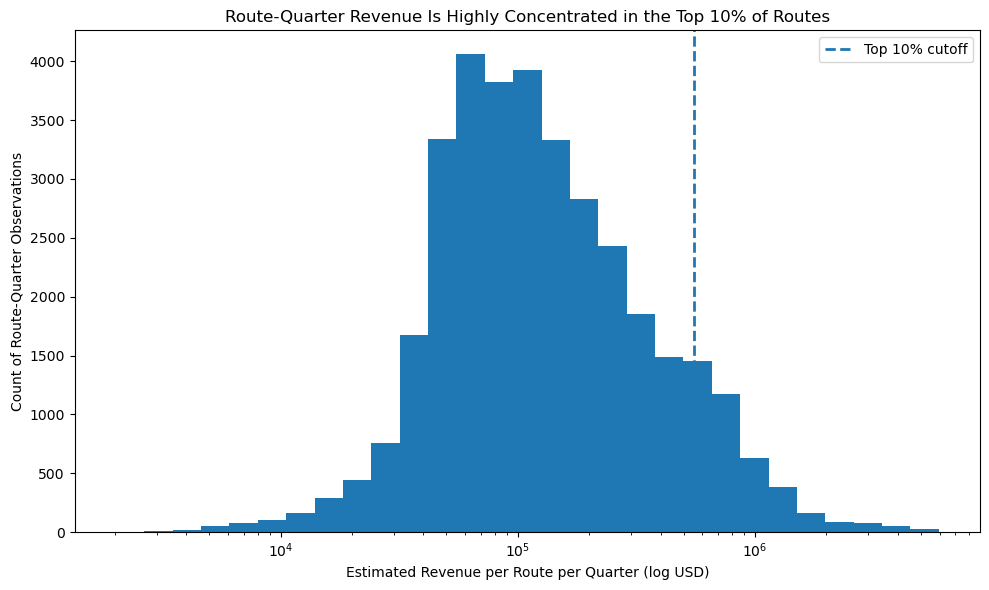

In [152]:
#Comparing top 10% revenue routes vs. bottom 90%
p90 = route_quarter_agg['estimated_revenue'].quantile(0.90)

plt.close('all')

plt.figure(figsize=(10,6))

# Histogram
plt.hist(
    route_quarter_agg['estimated_revenue'],
    bins=np.logspace(
        np.log10(route_quarter_agg['estimated_revenue'].min()),
        np.log10(route_quarter_agg['estimated_revenue'].max()),
        30
    )
)
plt.xscale('log')

# 90th Percentile cut line
plt.axvline(p90, linestyle='--', linewidth=2, label='Top 10% cutoff')

plt.title('Route-Quarter Revenue Is Highly Concentrated in the Top 10% of Routes')
plt.xlabel('Estimated Revenue per Route per Quarter (log USD)')
plt.ylabel('Count of Route-Quarter Observations')
plt.legend()

plt.tight_layout()
plt.show()


# Route-level revenue is highly concentrated: most routes generate modest quarterly revenue,while the top 10% of routes dominate overall revenue generation. This pattern indicates that airline profitability depends heavily on a small number of consistently high-performing routes. The top 10% of route-quarters account for approximately 45% of total estimated revenue

In [170]:
route_year_agg['revenue_decile'] = (
    route_year_agg
    .groupby('year')['estimated_revenue']
    .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1)
)

route_year_agg['route_performance_group'] = route_year_agg['revenue_decile'].apply(
    lambda x: 'Bottom 10%' if x == 1 else 'Top 10%' if x == 10 else 'Middle 80%'
)

I created revenue deciles to rank route-year observations by estimated revenue. This allowed me to compare the highest-performing 10% of routes against the lowest-performing 10% and identify whether revenue differences were driven more by passenger demand, fare levels, or distance

In [174]:
print(route_year_agg['revenue_decile'])

0       4
1       4
2       4
3       4
4       4
       ..
9755    8
9756    8
9757    7
9758    8
9759    1
Name: revenue_decile, Length: 9760, dtype: int64


In [176]:
route_year_agg['estimated_revenue'].quantile([0.90, 0.95, 0.99])

0.90   2,036,603.80
0.95   2,940,845.10
0.99   5,896,607.45
Name: estimated_revenue, dtype: float64

In [156]:
len(route_quarter_agg)

34746

In [158]:
print(route_year_agg.columns.tolist())
print(route_year_agg.shape)
print(route_year_agg.head())

['city1', 'city2', 'year', 'distance', 'total_passengers', 'estimated_revenue', 'avg_fare', 'route', 'revenue_decile', 'route_performance_group']
(9760, 10)
        city1        city2  year  distance  total_passengers  \
0  Albany, NY  Chicago, IL  2010    723.00              1239   
1  Albany, NY  Chicago, IL  2011    723.00              1228   
2  Albany, NY  Chicago, IL  2012    723.00              1207   
3  Albany, NY  Chicago, IL  2013    723.00              1177   
4  Albany, NY  Chicago, IL  2014    723.00              1202   

   estimated_revenue  avg_fare                     route  revenue_decile  \
0         252,144.06    203.51  Albany, NY → Chicago, IL               4   
1         273,608.11    222.81  Albany, NY → Chicago, IL               4   
2         287,805.90    238.45  Albany, NY → Chicago, IL               4   
3         295,396.67    250.97  Albany, NY → Chicago, IL               4   
4         311,306.85    258.99  Albany, NY → Chicago, IL               4   

 

In [160]:
print(len(route_year_agg))

9760


In [162]:
route_quarter_agg.to_csv("route_quarter_agg_tableau.csv", index=False)

In [164]:
route_year_agg.to_csv("route_year_agg_tableau.csv", index=False)

In [166]:
import os
print(os.getcwd())

/Users/emjack5/Desktop/Data analysis/Capstone2 files


# To better understand what separates high-revenue routes from the broader market, the Tableau analysis compares the top 10% of routes against the remaining 90% across passenger volume, average fare, and distance. This helps identify whether revenue performance is driven more by demand, pricing, or route characteristics.

## Analysis Focus Areas in Tableau

The following issues are derived from the capstone issue tree:

1. **Route Revenue Trends**
   - Which routes generate the highest estimated revenue?
   - How concentrated is revenue among the top-performing routes?
     
2.  **Drivers of Revenue**
   - Do high-revenue routes have higher passenger volume, higher fares, or longer distances?
   - What differentiates top 10% routes from lower-performing routes?

3. **Performance Over Time**
   - How did passenger volume, average fare, and estimated revenue change from 2010 to 2023?
   - How did major disruptions, such as COVID-19, affect route performance?

4. **Strategic Recommendations**
   - Which route characteristics should airlines prioritize?
   - Should airlines focus more on increasing demand, adjusting fares, or reallocating service?


## Assumptions & Limitations

- Estimated revenue is calculated as fare × passengers.
- No cost, margin, or operating expense data is included, so this analysis does not measure true profitability.
- Analysis is limited to complete full-year observations from 2010 to 2023.
- Routes are defined as directional city pairs using city1 → city2.
- Revenue performance is evaluated at the route-year level for final analysis.